# IMDB Sentiment Analysis

This notebook walks through building **two sentiment classifiers** on the IMDB movie review dataset, step by step.

| Model | Representation | Architecture |
|-------|---------------|--------------|
| A | TF-IDF bigrams | MLP |
| B | GloVe pre-trained embeddings | Bidirectional GRU |

**What you'll learn:**
- How to clean raw HTML text using a custom standardizer baked into Keras
- How to represent text as TF-IDF vectors vs integer token sequences
- How to load and use pre-trained GloVe word embeddings
- How to build, train, and compare two different model families

**Prerequisites:**
- Download IMDB text dataset:
    - https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
- Download GloVe embeddings before running Model B:
    - https://nlp.stanford.edu/data/glove.6B.zip

## 1- Imports & Hyperparameters

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TF logging
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Suppress oneDNN messages
os.environ["CUDA_VISIBLE_DEVICES"] = '0'
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
tf.get_logger().setLevel('ERROR')  # Only show errors

In [27]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers

# ── Hyperparameters ────────────────────────────────────────────────────────────
BATCH_SIZE    = 32      # number of reviews per training step
MAX_TOKENS    = 10_000  # vocabulary size cap (top-N most frequent tokens)
SEQ_LENGTH    = 200     # fixed sequence length for the LSTM (tokens per review)
EMBEDDING_DIM = 50      # GloVe vector size — must match the downloaded file (50/100/200/300)
EPOCHS        = 10      # maximum training epochs (early stopping will cut this short)
VAL_SPLIT     = 0.2     # 20% of training data reserved for validation
GLOVE_PATH    = f"glove.6B.{EMBEDDING_DIM}d.txt"
SEED          = 42

AUTOTUNE = tf.data.AUTOTUNE  # let TensorFlow decide parallelism at runtime

print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")
print(f"GPU devices : {tf.config.list_physical_devices('GPU')}")

TensorFlow  : 2.21.0
Keras       : 3.14.1
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2- Load the IMDB Dataset

The IMDB dataset contains 50,000 movie reviews
evenly split between positive and negative sentiment.

The directory structure on disk looks like:
```
aclImdb/
  train/
    pos/   ← 12,500 positive reviews (.txt files)
    neg/   ← 12,500 negative reviews
    unsup/ ← 50,000 unlabelled reviews (we remove this)
  test/
    pos/   ← 12,500
    neg/   ← 12,500
```

`text_dataset_from_directory` infers labels from folder names, so we must delete `unsup/`
first — otherwise Keras sees three classes instead of two.

We also split the 25,000 training examples into **80% train / 20% validation** using
the same `seed=42` for both subsets so the splits are complementary and non-overlapping.

In [3]:
dataset_dir = pathlib.Path('aclImdb')
train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'

In [4]:
print('===== Finding Train Files ... =====')
raw_train_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED
)
print('===== Finding Validation Files ... =====')
raw_val_ds = keras.utils.text_dataset_from_directory(
    train_dir,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED
)
print('===== Finding Test Files ... =====')
raw_test_ds = keras.utils.text_dataset_from_directory(
    test_dir,
    batch_size=BATCH_SIZE,
)
print('=' * 20)
for texts, labels in raw_train_ds.take(1):
    print(f'Batch shape: {texts.shape}')
    print(f'Label shape: {labels.shape}')
    print(f'Sample review (raw): {texts[0].numpy().decode()[:150]}...')
    print(f'Label: {"positive" if labels[0] else "negative"}')

===== Finding Train Files ... =====
Found 25000 files belonging to 2 classes.
Using 20000 files for training.
===== Finding Validation Files ... =====
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
===== Finding Test Files ... =====
Found 25000 files belonging to 2 classes.
Batch shape: (32,)
Label shape: (32,)
Sample review (raw): "Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "A...
Label: negative


## 3- Custom Text Standardizer

Raw IMDB reviews contain HTML artifacts left over from web scraping — most commonly
`<br />` line-break tags. If we don't remove them, `<br` and `/>` enter the vocabulary
as meaningless high-frequency tokens, wasting capacity.

**Cleaning steps (in order)**
| Step | Pattern | Why |
|------|---------|-----|
| Lowercase | — | `Good` and `good` should be the same token |
| Strip HTML tags | `<[^>]+>` | Removes `<br />`, `<p>`, `<i>`, etc. |
| Strip HTML entities | `&[a-z]+;` | Removes `&amp;`, `&nbsp;`, `&quot;`, etc. |
| Strip punctuation | `[^a-z\s]` | Keeps only letters and spaces |
| Collapse whitespace | `\s+` | Turns multiple spaces/newlines into a single space |

In [5]:
@tf.function
def custom_standardize(text: tf.Tensor) -> tf.Tensor:
    """
    Clean a batch of raw review strings.
    All operations use tf.strings so the function runs inside the TF graph —
    no Python-level loop, no GIL, fully parallelisable by tf.data.
    """
    text = tf.strings.lower(text)                              # lowercase everything
    text = tf.strings.regex_replace(text, r"<[^>]+>", " ")   # strip HTML tags
    text = tf.strings.regex_replace(text, r"&[a-z]+;", " ")  # strip HTML entities
    text = tf.strings.regex_replace(text, r"[^a-z\s]", " ")  # strip punctuation/numbers
    text = tf.strings.regex_replace(text, r"\s+", " ")        # collapse whitespace
    text = tf.strings.strip(text)                              # trim leading/trailing spaces
    return text

# Verify with a realistic example
sample = tf.constant(["A <br /> great film! &amp; well-acted. 10/10"])
cleaned = custom_standardize(sample)
print(f"Before: {sample.numpy()[0].decode()}")
print(f"After : {cleaned.numpy()[0].decode()}")

Before: A <br /> great film! &amp; well-acted. 10/10
After : a great film well acted


## 4- Dataset Utilities

Two small helpers used throughout:

- **`make_text_only`** — strips labels from a dataset so we can pass it to
  `vectorizer.adapt()`, which only needs the text.
- **`vectorize_ds`** — applies a fitted vectorizer to a `(text, label)` dataset
  and adds `.cache().prefetch()` for performance.

### Why `.cache().prefetch(AUTOTUNE)`?

- **`.cache()`** stores the vectorized tensors in memory after the first epoch,
  so subsequent epochs skip the (slow) vectorization step entirely.
- **`.prefetch(AUTOTUNE)`** overlaps data preparation for batch N+1 while the
  GPU is busy training on batch N, eliminating the input pipeline bottleneck.

In [6]:
def make_text_only(ds: tf.data.Dataset) -> tf.data.Dataset:
    """Drop labels — used to feed plain text into vectorizer.adapt()."""
    return ds.map(lambda x, y: x, num_parallel_calls=AUTOTUNE)


def vectorize_ds(
    ds: tf.data.Dataset,
    vectorizer: layers.TextVectorization,
) -> tf.data.Dataset:
    """
    Apply a fitted TextVectorization layer to a (text, label) dataset.
    Adds cache + prefetch for maximum pipeline throughput.
    """
    return (
        ds
        .map(lambda x, y: (vectorizer(x), y), num_parallel_calls=AUTOTUNE)
        .cache()      # store in RAM after first pass — skips vectorization on later epochs
        .prefetch(AUTOTUNE)  # prepare next batch while GPU trains on current one
    )

# Build the text-only dataset once — shared by both vectorizers
text_only_ds = make_text_only(raw_train_ds)

## Model A: TF-IDF + Bigram + MLP

### Vectorization

In [7]:
tfidf_vectorizer = layers.TextVectorization(
    standardize=custom_standardize,  # HTML cleaning baked in
    max_tokens=MAX_TOKENS,           # vocabulary cap
    output_mode="tf-idf",            # output a TF-IDF weighted vector
    ngrams=2,                        # include unigrams AND bigrams
)

# adapt() scans the training corpus to build vocabulary + IDF weights
# Pass text-only (no labels) — adapt() doesn't need them
print("Adapting TF-IDF vectorizer on training corpus...")
tfidf_vectorizer.adapt(text_only_ds)

Adapting TF-IDF vectorizer on training corpus...


In [8]:
vocab = tfidf_vectorizer.get_vocabulary()
print(f"Vocabulary size : {len(vocab):,}")
print(f"Top 20 tokens   : {[str(v) for v in vocab[:20]]}")

Vocabulary size : 10,000
Top 20 tokens   : ['[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this', 'that', 's', 'was', 'as', 'for', 'movie', 'with', 'but', 'film']


In [9]:
# Vectorize all three splits
train_tfidf = vectorize_ds(raw_train_ds, tfidf_vectorizer)
val_tfidf   = vectorize_ds(raw_val_ds,   tfidf_vectorizer)
test_tfidf  = vectorize_ds(raw_test_ds,  tfidf_vectorizer)

# Confirm output shape: (batch_size, MAX_TOKENS)
for vecs, labels in train_tfidf.take(1):
    print(f"\nVectorized batch shape: {vecs.shape}")
    print(f"Non-zero entries in first review: {tf.math.count_nonzero(vecs[0]).numpy()}")


Vectorized batch shape: (32, 10000)
Non-zero entries in first review: 353


### MLP Model

### Architecture
```
Input (20,000)  →  Dense(32, ReLU)  →  Dropout(0.3)
                →  Dense(16, ReLU)  →  Dropout(0.2)
                →  Dense(1, Sigmoid)   [binary output]
```

In [10]:
def build_mlp_bigram(max_tokens: int) -> keras.Model:
    """TF-IDF bigram → MLP binary classifier."""
    inp = layers.Input(shape=(max_tokens,), name="tfidf_input")

    # First hidden layer — wider to capture diverse TF-IDF patterns
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)  # drop 30% of neurons to regularize the large input

    # Second hidden layer — narrower bottleneck forces compression
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    # Output: single neuron with sigmoid → probability in [0, 1]
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inp, out, name="mlp_bigram_tfidf")
    model.compile(
        # 3e-3: higher than default 1e-3 to compensate for dropout slowing gradients
        optimizer=keras.optimizers.Adam(3e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model_mlp = build_mlp_bigram(MAX_TOKENS)
model_mlp.summary()

Model: "mlp_bigram_tfidf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)        │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,577 (1.22 MB)

 Trainable params: 320,577 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

### Training

In [11]:
def get_callbacks(model_name: str) -> list:
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,               # stop after 3 epochs of no improvement
            restore_best_weights=True,# revert to the epoch with the best val_accuracy
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,   # multiply LR by 0.5 on plateau  (3e-3 → 1.5e-3 → 7.5e-4 …)
            patience=2,   # wait 2 stagnant epochs before reducing
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor="val_accuracy",
            save_best_only=True,  # only overwrite when val_accuracy improves
            verbose=1,
        ),
    ]

print("Training MLP — TF-IDF Bigram Model")
print("=" * 50)

history_mlp = model_mlp.fit(
    train_tfidf,
    validation_data=val_tfidf,
    epochs=EPOCHS,
    callbacks=get_callbacks("mlp_bigram"),
)

Training MLP — TF-IDF Bigram Model
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6732 - loss: 0.9451
Epoch 1: val_accuracy improved from None to 0.87000, saving model to mlp_bigram_best.keras

Epoch 1: finished saving model to mlp_bigram_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7700 - loss: 0.5400 - val_accuracy: 0.8700 - val_loss: 0.3064 - learning_rate: 0.0030
Epoch 2/10
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8746 - loss: 0.3226
Epoch 2: val_accuracy improved from 0.87000 to 0.88220, saving model to mlp_bigram_best.keras

Epoch 2: finished saving model to mlp_bigram_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8776 - loss: 0.3028 - val_accuracy: 0.8822 - val_loss: 0.2849 - learning_rate: 0.0030
Epoch 3/10
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8959 - loss: 0.2487
Epoch 3: val_accuracy did not improve from 0.88220
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8931 - loss: 0.2493 

In [22]:
loss_mlp, acc_mlp = model_mlp.evaluate(test_tfidf, verbose=0)
print(f"BiLSTM Test Loss     : {loss_mlp:.4f}")
print(f"BiLSTM Test Accuracy : {acc_mlp*100:.2f}%")

BiLSTM Test Loss     : 0.5123
BiLSTM Test Accuracy : 88.50%


## Model B: GloVe Embedding + Bidirectional GRU

### Vectorization

In [12]:
int_vectorizer = layers.TextVectorization(
    standardize=custom_standardize,      # same cleaning as the TF-IDF vectorizer
    max_tokens=MAX_TOKENS,
    output_mode="int",                   # integer token IDs, not TF-IDF weights
    output_sequence_length=SEQ_LENGTH,   # pad/truncate to fixed length
    # Note: no ngrams here — the GRU learns positional patterns directly from the sequence
)

print("Adapting integer vectorizer on training corpus...")
int_vectorizer.adapt(text_only_ds)

train_int = vectorize_ds(raw_train_ds, int_vectorizer)
val_int   = vectorize_ds(raw_val_ds,   int_vectorizer)
test_int  = vectorize_ds(raw_test_ds,  int_vectorizer)

# Output shape is (batch_size, SEQ_LENGTH) — a sequence of token IDs
for seqs, labels in train_int.take(1):
    print(f"\nSequence batch shape : {seqs.shape}")
    print(f"First 20 token IDs   : {seqs[0, :20].numpy()}")

Adapting integer vectorizer on training corpus...

Sequence batch shape : (32, 200)
First 20 token IDs   : [9013   16   30    5    2  247  100    5   31   57    4   54  898  972
   36  268   39    8 3877   38]


### Using GloVe Pre-trained Embedding

In [13]:
def load_glove(path: str) -> dict:
    """Load GloVe vectors into a {word: numpy_array} dictionary."""
    index = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            index[parts[0]] = np.asarray(parts[1:], dtype="float32")
    return index


def build_embedding_matrix(
    vocabulary: list,
    glove_index: dict,
    max_tokens: int,
    embedding_dim: int,
) -> np.ndarray:
    """
    Build a (max_tokens, embedding_dim) matrix.
    Row i = GloVe vector for the word at vocabulary index i.
    Words absent from GloVe remain zero-vectors.
    """
    word_to_idx = {word: i for i, word in enumerate(vocabulary)}
    matrix = np.zeros((max_tokens, embedding_dim), dtype="float32")
    hits = 0
    for word, idx in word_to_idx.items():
        if idx >= max_tokens:
            continue
        vec = glove_index.get(word)
        if vec is not None:
            matrix[idx] = vec
            hits += 1
    coverage = hits / min(len(word_to_idx), max_tokens) * 100
    print(f"GloVe coverage: {hits:,} / {min(len(word_to_idx), max_tokens):,} tokens ({coverage:.1f}%)")
    return matrix


print(f"Loading GloVe from: {GLOVE_PATH}")
glove_index = load_glove(GLOVE_PATH)
print(f"GloVe vocabulary size: {len(glove_index):,}")

embedding_matrix = build_embedding_matrix(
    int_vectorizer.get_vocabulary(),
    glove_index,
    MAX_TOKENS,
    EMBEDDING_DIM,
)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading GloVe from: glove.6B.50d.txt
GloVe vocabulary size: 400,000
GloVe coverage: 9,986 / 10,000 tokens (99.9%)
Embedding matrix shape: (10000, 50)


### GRU Model

In [16]:
def build_glove_bilstm(
    embedding_matrix: np.ndarray,
    seq_length: int,
    max_tokens: int,
    embedding_dim: int,
) -> keras.Model:
    """GloVe embedding → stacked Bidirectional LSTM → binary classifier."""

    # Pre-trained GloVe weights loaded via the `weights` argument
    # trainable=False: freeze the embeddings — don't let backprop overwrite GloVe
    embedding_layer = layers.Embedding(
        input_dim=max_tokens,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False,
        name="glove_embedding",
    )

    inp = layers.Input(shape=(seq_length,), name="int_input")
    x = embedding_layer(inp)                                 # (batch, 200, 50)

    # First BiLSTM: return_sequences=True passes per-step outputs to the next layer
    x = layers.Bidirectional(layers.GRU(32, return_sequences=True))(x)  # (batch, 200, 32)

    # Second BiLSTM: return_sequences=False (default) → single summary vector
    x = layers.Bidirectional(layers.GRU(16))(x)            # (batch, 16)

    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)

    model = keras.Model(inp, out, name="glove_bilstm")
    model.compile(
        optimizer=keras.optimizers.Adam(3e-3),  # elevated LR to offset dropout
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model_lstm = build_glove_bilstm(embedding_matrix, SEQ_LENGTH, MAX_TOKENS, EMBEDDING_DIM)
model_lstm.summary()

Model: "glove_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ int_input (InputLayer)          │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 200, 50)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 64)        │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,545 (2.00 MB)

 Trainable params: 24,545 (95.88 KB)

 Non-trainable params: 500,000 (1.91 MB)

### Training

In [17]:
print("Training BiLSTM — GloVe Embedding Model")
print("=" * 50)

history_lstm = model_lstm.fit(
    train_int,
    validation_data=val_int,
    epochs=EPOCHS,
    callbacks=get_callbacks("glove_bilstm"),
)

Training BiLSTM — GloVe Embedding Model
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6122 - loss: 0.6288
Epoch 1: val_accuracy improved from None to 0.81000, saving model to glove_bilstm_best.keras

Epoch 1: finished saving model to glove_bilstm_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.7074 - loss: 0.5420 - val_accuracy: 0.8100 - val_loss: 0.4066 - learning_rate: 0.0030
Epoch 2/10
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8207 - loss: 0.4056
Epoch 2: val_accuracy improved from 0.81000 to 0.83480, saving model to glove_bilstm_best.keras

Epoch 2: finished saving model to glove_bilstm_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.8246 - loss: 0.3934 - val_accuracy: 0.8348 - val_loss: 0.3676 - learning_rate: 0.0030
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8449 - loss: 0.3603
Epoch 3: val_accuracy improved from 0.83480 to 0.83980, saving model to glove_bilstm_best.keras

Epoch 3: 

In [31]:
loss_gru, acc_gru = model_lstm.evaluate(test_int, verbose=0)
print(f"BiGRU Test Loss     : {loss_gru:.4f}")
print(f"BiGRU Test Accuracy : {acc_gru*100:.2f}%")

BiGRU Test Loss     : 0.3724
BiGRU Test Accuracy : 84.30%


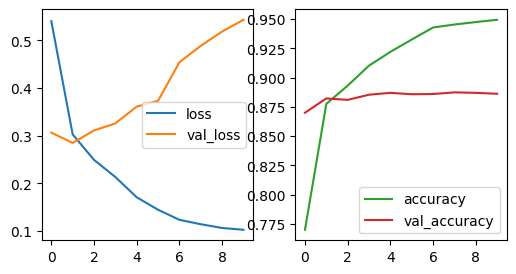

In [28]:
history_mlp_df = pd.DataFrame(history_mlp.history)
history_mlp_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    subplots=(['loss', 'val_loss'], ['accuracy', 'val_accuracy']),
    figsize=(6,3), layout=(1, 2)
)
plt.show()

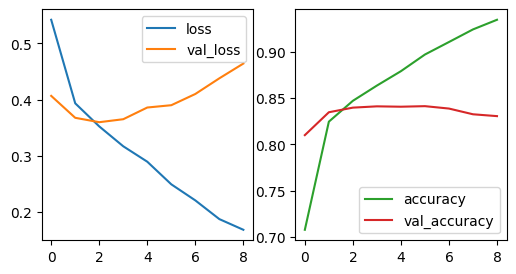

In [29]:
history_gru_df = pd.DataFrame(history_lstm.history)
history_gru_df[['loss', 'val_loss', 'accuracy', 'val_accuracy']].plot(
    subplots=(['loss', 'val_loss'], ['accuracy', 'val_accuracy']),
    figsize=(6,3), layout=(1, 2)
)
plt.show()

## Final Comparision

Both models tackle the same problem with fundamentally different inductive biases:

| | MLP + TF-IDF | BiGRU + GloVe |
|--|--|--|
| **Word order** | Ignored (bag of words) | Preserved |
| **Phrase context** | Bigrams only | Full sequence context |
| **Word meaning** | Frequency-based | Pre-trained semantic vectors |
| **Speed** | Very fast | Slower (sequential GRU) |
| **Typical accuracy** | ~88–90% | ~88–92% |

In [30]:
print("=" * 40)
print("       Final Test Results")
print("=" * 40)
print(f"  MLP  (TF-IDF bigram) : {acc_mlp*100:.2f}%")
print(f"  BiLSTM  (GloVe)      : {acc_gru*100:.2f}%")
print("=" * 40)

winner = "MLP" if acc_mlp >= acc_gru else "BiLSTM"
print(f"\nBetter on this run: {winner}")
print("""
Note: TF-IDF MLPs often match or beat LSTMs on short classification
tasks because the bag-of-words signal is already strong for sentiment.
LSTMs tend to win when long-range context or negation patterns matter.
""")

       Final Test Results
  MLP  (TF-IDF bigram) : 88.50%
  BiLSTM  (GloVe)      : 84.30%

Better on this run: MLP

Note: TF-IDF MLPs often match or beat LSTMs on short classification
tasks because the bag-of-words signal is already strong for sentiment.
LSTMs tend to win when long-range context or negation patterns matter.

